# 02 - Preprocesamiento de imagenes y OpenMP

Este notebook explica como una imagen real se transforma en el vector que recibe el MLP. Tambien muestra donde entra OpenMP dentro del flujo del proyecto.

Flujo general: imagen original -> escala de grises -> recorte de zona de boca -> redimensionamiento -> filtro Gaussiano -> normalizacion -> aplanamiento.


## Bloque 1: preparar entorno del notebook

Este bloque importa OpenCV, NumPy y Matplotlib para leer imagenes y visualizar cada etapa del preprocesamiento. Tambien carga las constantes reales del proyecto, como `IMAGE_SIZE = 64x64` y `OPENMP_INPUT_SIZE = 128x128`.


In [7]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DATASET_DIR, IMAGE_SIZE, OPENMP_INPUT_SIZE, PREPROCESSING_STRATEGY
from src.preprocessing import VALID_EXTENSIONS, crop_mouth_region, preprocess_image

IMAGE_SIZE, OPENMP_INPUT_SIZE, PREPROCESSING_STRATEGY


((64, 64), (128, 128), 'lower_face')

## Bloque 2: seleccionar imagenes de ejemplo

Este bloque toma algunas imagenes de `no_yawn` y `yawn` desde el conjunto de entrenamiento. Se usan ejemplos de ambas clases para comprobar que el recorte de boca funciona de forma consistente.


In [8]:
def list_images(split, class_name, limit=3):
    folder = DATASET_DIR / split / class_name
    images = [path for path in sorted(folder.rglob("*")) if path.suffix.lower() in VALID_EXTENSIONS]
    return images[:limit]

sample_paths = list_images("train", "no_yawn", 3) + list_images("train", "yawn", 3)
for path in sample_paths:
    print(path.relative_to(ROOT))


datasets/train/no_yawn/00.jpg
datasets/train/no_yawn/00001-2876027730.png
datasets/train/no_yawn/00009-2876027738.png
datasets/train/yawn/00001-2515102071.png
datasets/train/yawn/00001-3037815734.png
datasets/train/yawn/00002-227722405.png


## Bloque 3: visualizar escala de grises, recorte y normalizacion

Este bloque muestra el procesamiento paso a paso. Primero lee la imagen original, luego la convierte a gris, recorta la zona inferior del rostro donde esta la boca y finalmente genera la imagen normalizada de 64x64 que recibe el MLP.

El recorte se hace en `src/preprocessing.py`, dentro de `crop_mouth_region()`. Si se detecta un rostro, se toma principalmente la parte inferior del rostro. Si no se detecta, se usa un recorte de respaldo para retratos centrados.


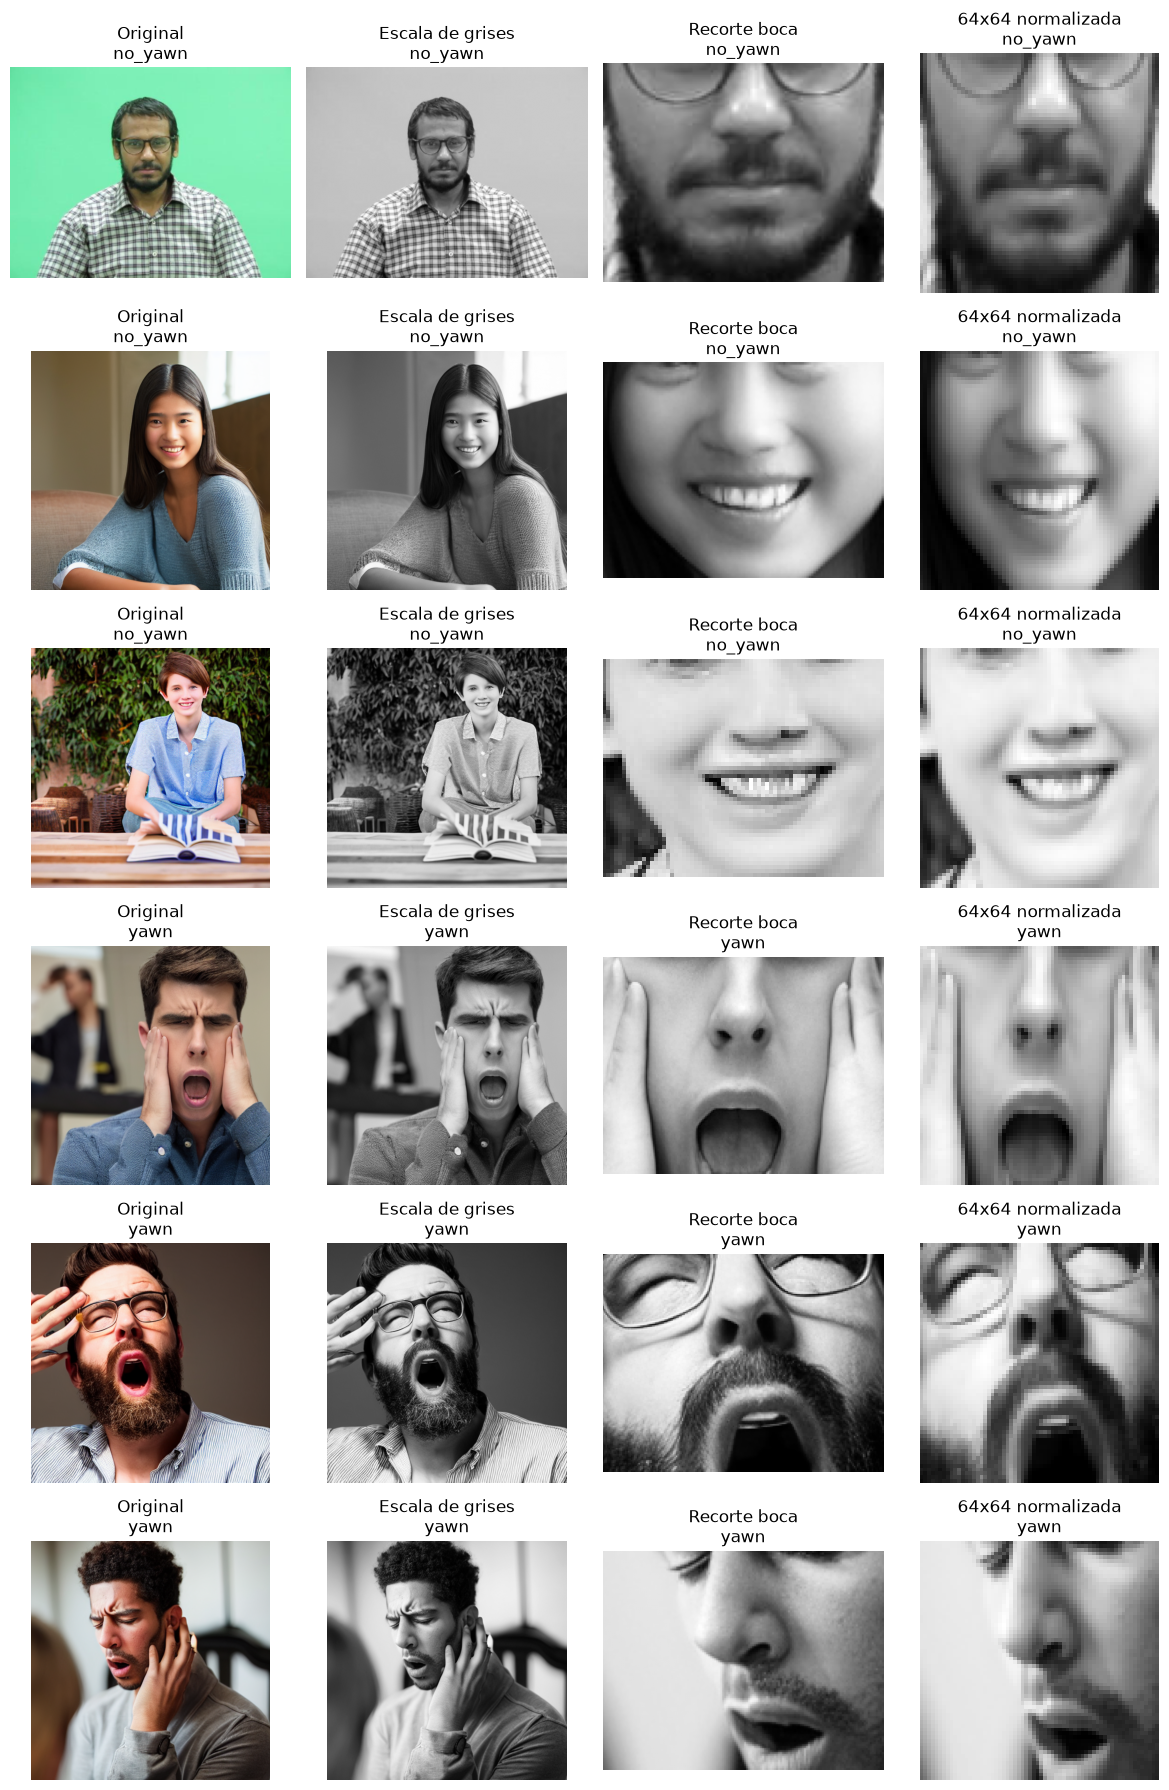

In [9]:
def show_preprocessing_steps(paths):
    columns = 4
    rows = len(paths)
    fig, axes = plt.subplots(rows, columns, figsize=(12, 3 * rows))
    if rows == 1:
        axes = np.array([axes])

    for row, path in enumerate(paths):
        image_bgr = cv2.imread(str(path))
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        crop = crop_mouth_region(gray)
        vector = preprocess_image(path)
        normalized_64 = vector.reshape(IMAGE_SIZE)

        images = [image_rgb, gray, crop, normalized_64]
        titles = ["Original", "Escala de grises", "Recorte boca", "64x64 normalizada"]
        cmaps = [None, "gray", "gray", "gray"]

        for col in range(columns):
            axes[row, col].imshow(images[col], cmap=cmaps[col])
            axes[row, col].set_title(f"{titles[col]}\n{path.parent.name}")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

show_preprocessing_steps(sample_paths)


## Bloque 4: comprobar el vector final que entra al MLP

Despues del preprocesamiento, cada imagen queda como un vector de 4096 valores porque `64 x 64 = 4096`. Los valores estan normalizados entre 0 y 1 para que la red neuronal entrene de forma estable.


In [10]:
if sample_paths:
    vector = preprocess_image(sample_paths[0])
    print("Forma del vector:", vector.shape)
    print("Valor minimo:", float(vector.min()))
    print("Valor maximo:", float(vector.max()))
    print("Primeros 10 valores:", vector[:10])


Forma del vector: (4096,)
Valor minimo: 0.03934592381119728
Valor maximo: 0.8677844405174255
Primeros 10 valores: [0.17916666 0.33201835 0.47538903 0.5124183  0.45584735 0.32908496
 0.4530462  0.49362746 0.47205105 0.46383053]


## Bloque 5: explicar que mide OpenMP

OpenMP no entrena el modelo. OpenMP mide el preprocesamiento serial contra el preprocesamiento paralelo sobre todas las imagenes exportadas. La comparacion incluye escala de grises, filtro Gaussiano, redimensionamiento, normalizacion y aplanamiento.

El recorte de boca ocurre antes, en Python, para dejar entradas centradas en la zona importante. Luego OpenMP procesa esas regiones de forma serial y paralela.


In [11]:
openmp_report = ROOT / "metrics" / "openmp_benchmark.md"
if openmp_report.exists():
    display(Markdown(openmp_report.read_text(encoding="utf-8")))
else:
    print("Aun no existe el reporte OpenMP. Se genera al ejecutar manualmente: python -m src.train")


# Preprocesamiento: serial vs OpenMP

Alcance: una pasada completa sobre todas las imagenes de entrenamiento, validacion y prueba en memoria. Incluye escala de grises, Gaussiano, resize, normalizacion y flatten. Excluye lectura/escritura de archivos, recorte facial, inferencia y entrenamiento.

| Modo | Hilos | Imagenes | Tiempo (ms) | Speedup |
|---|---:|---:|---:|---:|
| Serial | 1 | 630 | 95.792 | 1.000x |
| OpenMP | 8 | 630 | 24.347 | 3.934x |


## Bloque 6: mostrar la grafica de speedup OpenMP

El speedup se calcula como `tiempo serial / tiempo paralelo`. Si el valor es mayor que 1, el procesamiento paralelo fue mas rapido. Esta grafica sirve como evidencia para la parte de programacion paralela.


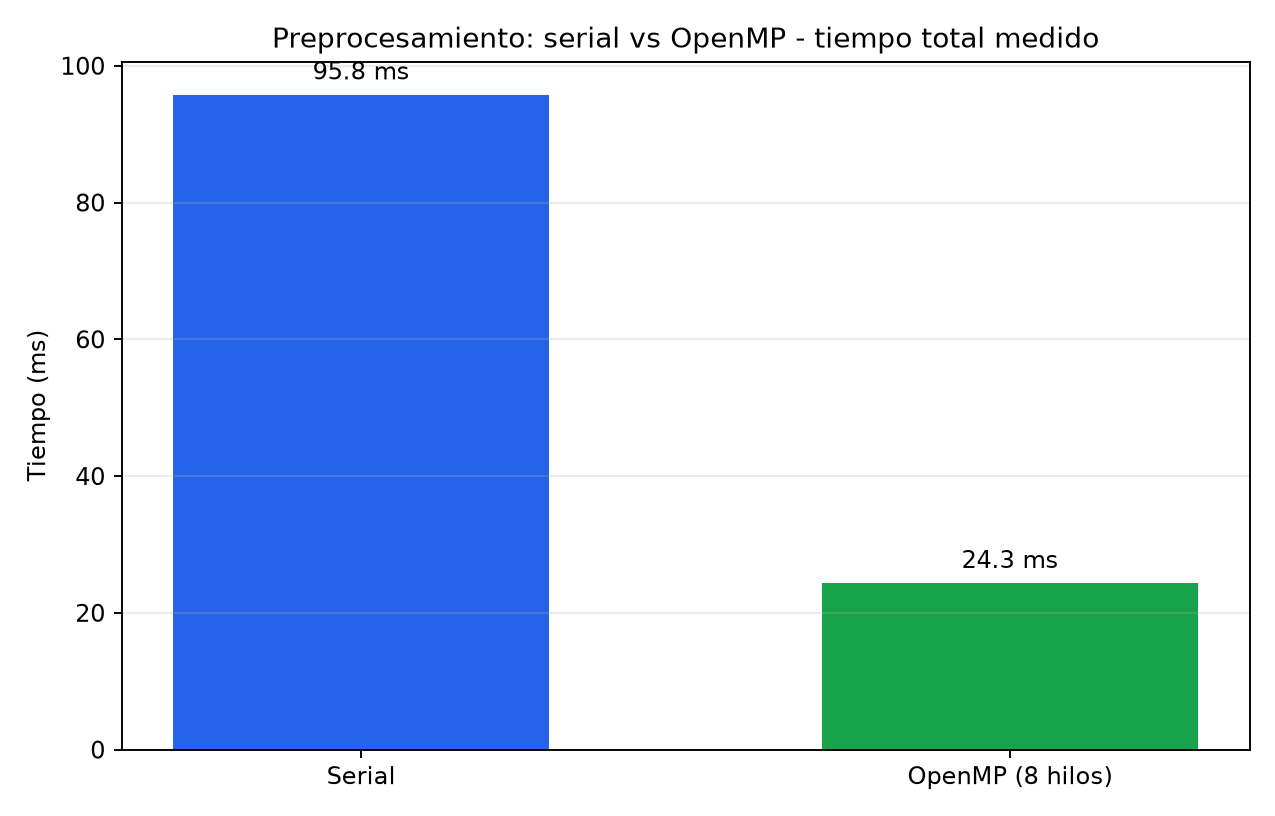

In [12]:
openmp_chart = ROOT / "metrics" / "openmp_speedup.png"
if openmp_chart.exists():
    display(Image(filename=str(openmp_chart)))
else:
    print("La grafica OpenMP todavia no existe. Se genera despues de ejecutar el flujo de entrenamiento.")
